# 1 — Train SFM-Time and draw samples

SFM-Time partitions flow time into $K$ contiguous segments and gives each its own
small stack of velocity blocks, while one shared representation trunk conditions
every stack per time step. Sampling walks the segments from noise to data with
$M$ Euler steps inside each, so the cost is $\mathrm{NFE}=KM$.

This notebook trains one model and draws samples from it. It writes
`results/run/<dataset>_sfmtime/`, which notebooks 2 and 3 read, so running the
three in order needs no arguments.

Defaults are the reported configuration. Lower `STEPS` for a faster look.

In [1]:
import os
# torch and scikit-learn each bring their own OpenMP runtime; inside a Jupyter
# kernel the two can collide and take the kernel down when t-SNE runs after a
# torch import. Capping the thread pools before either is imported avoids it.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import sys, json, time
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import torch
import matplotlib.pyplot as plt

from sfmtime import SFMTimeConfig, ModelConfig, FlowConfig, TrainConfig, SFMTimeTrainer
from sfmtime.data import make_dataset, split

plt.rcParams.update({"figure.dpi": 120, "font.size": 8,
                     "axes.spines.top": False, "axes.spines.right": False})
REAL_C, GEN_C = "#A82424", "#17548C"

## Configuration

`DATASET` picks the benchmark. The sequence length and width below are the
reported settings for each one; Energy uses width 128 and the rest 96.

In [2]:
DATASET   = "sines"          # sines | stocks | energy | ecg
STEPS     = 6000             # optimizer steps (the reported setting)
NFE       = 80               # function evaluations per sample = SEGMENTS x steps/segment
SEGMENTS  = 4                # K
SEG_DEPTH = 2                # velocity blocks per segment
REP_DEPTH = 4                # blocks in the shared trunk
N_GEN     = 3000             # sequences to generate for scoring

SEQ_LEN = {"sines": 64, "energy": 96, "stocks": 128, "ecg": 192}[DATASET]
D_MODEL = {"sines": 96, "energy": 128, "stocks": 96, "ecg": 96}[DATASET]
assert NFE % SEGMENTS == 0, "NFE must divide evenly across the segments"

## Data

Windows are cut with stride 1 and each feature is scaled to $[-1,1]$ over all
windows, then split 80/10/10. `scripts/export_splits.py` writes the same arrays
to `data/splits/` so that any other method can be trained and scored on exactly
these sequences.

In [3]:
X, scaler, meta = make_dataset(DATASET, seed=0, seq_len=SEQ_LEN)
Xtr, Xva, Xte = split(X, seed=0)
N_FEATURES = int(meta["n_features"])
print(f"{DATASET}: train {tuple(Xtr.shape)}  val {tuple(Xva.shape)}  test {tuple(Xte.shape)}")
print(f"value range [{float(X.min()):.2f}, {float(X.max()):.2f}]")

sines: train (8000, 64, 4)  val (1000, 64, 4)  test (1000, 64, 4)
value range [-1.00, 1.00]


## Model

The partition is uniform in flow time, $\sigma_k = 1 - k/K$, so segment $k$ owns
$(\sigma_{k+1}, \sigma_k]$ with segment 0 at the noise end. The model holds
$L_\mathrm{rep} + K L_\mathrm{seg}$ blocks but evaluates only
$L_\mathrm{rep} + L_\mathrm{seg}$ of them per step, which is what sets sampling
cost.

In [4]:
cfg = SFMTimeConfig(
    model=ModelConfig(seq_len=SEQ_LEN, n_features=N_FEATURES, d_model=D_MODEL,
                      segments=SEGMENTS, segment_depth=SEG_DEPTH, rep_depth=REP_DEPTH),
    flow=FlowConfig(segments=SEGMENTS, steps_per_segment=NFE // SEGMENTS),
    train=TrainConfig(steps=STEPS, batch_size=128, lr=1e-4, seed=0),
    name=f"sfmtime_{DATASET}",
)

trainer = SFMTimeTrainer(cfg, Xtr, X_val=Xva)
info = trainer.summary()
print(f"device {trainer.device}")
print(f"{info['params_total']:,} parameters held, "
      f"{info['params_active_per_step']:,} evaluated per step")
print(f"{info['blocks_active_per_step']} of {info['blocks_total']} blocks per step")
print(f"NFE {info['nfe']}  (segments {SEGMENTS} x {NFE // SEGMENTS} Euler steps)")

device mps
2,729,956 parameters held, 1,394,212 evaluated per step
6 of 12 blocks per step
NFE 80  (segments 4 x 20 Euler steps)


## Training

Each minibatch is split evenly across the segments and the interpolation time is
drawn inside each segment's own interval. That is a stratified estimator of the
usual flow-matching objective: it has the same optimum, and it updates every
segment's stack at every step instead of whichever one a uniform draw happened
to land in.

In [5]:
t0 = time.time()
trainer.train(STEPS)
train_min = (time.time() - t0) / 60
print(f"\ntrained in {train_min:.1f} min")

  step      0  loss 1.50959  denoise 1.50959  (0.7s)
  step    200  loss 0.50522  denoise 0.50522  (36.6s)
  step    400  loss 0.31745  denoise 0.31745  (72.6s)
  step    600  loss 0.28004  denoise 0.28004  (109.2s)
  step    800  loss 0.21226  denoise 0.21226  (146.3s)
  step   1000  loss 0.19993  denoise 0.19993  (183.4s)
  step   1200  loss 0.21619  denoise 0.21619  (220.5s)
  step   1400  loss 0.16766  denoise 0.16766  (257.8s)
  step   1600  loss 0.18477  denoise 0.18477  (293.5s)
  step   1800  loss 0.18546  denoise 0.18546  (329.1s)
  step   2000  loss 0.16497  denoise 0.16497  (364.9s)
  step   2200  loss 0.16287  denoise 0.16287  (400.8s)
  step   2400  loss 0.17440  denoise 0.17440  (437.9s)
  step   2600  loss 0.16896  denoise 0.16896  (477.9s)
  step   2800  loss 0.15555  denoise 0.15555  (515.8s)
  step   3000  loss 0.16337  denoise 0.16337  (552.4s)
  step   3200  loss 0.16836  denoise 0.16836  (590.8s)
  step   3400  loss 0.15209  denoise 0.15209  (628.3s)
  step   3600 

### Health check

Three failure modes are specific to this design and silent if unchecked: a
segment that never receives gradient, a wildly imbalanced per-segment residual,
and a sampler that returns constant or non-finite sequences.

In [6]:
health = trainer.health_check(verbose=False)
print(f"all segments receive gradient : {health['all_segments_get_gradient']}")
print(f"per-segment MSE               : {[round(v, 3) for v in health['per_segment_mse']]}")
print(f"imbalance (max/min)           : {health['segment_imbalance_ratio']}x")
print(f"samples finite, non-constant  : "
      f"{health['samples_finite']}, {health['samples_nonconstant']}")

all segments receive gradient : True
per-segment MSE               : [0.274, 0.121, 0.057, 0.125]
imbalance (max/min)           : 4.78x
samples finite, non-constant  : True, True


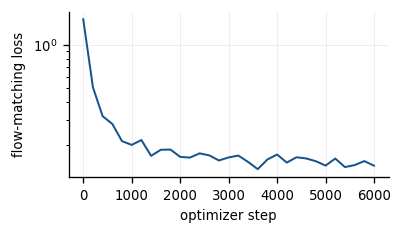

In [7]:
loss = [h["denoise"] for h in trainer.history]
step = [h["step"] for h in trainer.history]
fig, ax = plt.subplots(figsize=(3.4, 2.0))
ax.plot(step, loss, color=GEN_C, lw=1.2)
ax.set_yscale("log"); ax.set_xlabel("optimizer step"); ax.set_ylabel("flow-matching loss")
ax.grid(alpha=.25, lw=.5); fig.tight_layout(); plt.show()

## Sampling

Generation starts from $\mathbf{x}_{\sigma_0}=\varepsilon$ and integrates the
segments in order. Segment boundaries are hit exactly, so the stacks hand over
cleanly.

In [8]:
_ = trainer.generate(min(128, N_GEN))          # warm-up, excluded from the timing
t0 = time.time()
gen = trainer.generate(N_GEN)
ms = 1000 * (time.time() - t0) / N_GEN
print(f"generated {gen.shape} at {ms:.1f} ms/sequence, NFE {trainer.last_nfe}")

generated (3000, 64, 4) at 47.7 ms/sequence, NFE 80


## What the samples look like

Real sequences in dark red, generated in dark blue. Each panel is one channel;
traces are offset vertically so they do not overlap.

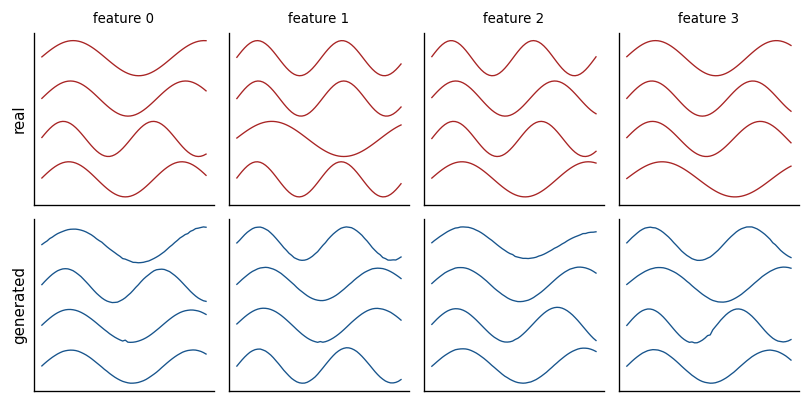

In [9]:
def strip(ax, batch, color, k, n=4, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(batch), n, replace=False)
    span = float(np.percentile(batch[:, :, k].max(1) - batch[:, :, k].min(1), 90)) or 1.0
    for m, i in enumerate(idx):
        ax.plot(batch[i, :, k] - m * 1.15 * span, color=color, lw=.8)
    ax.set_xticks([]); ax.set_yticks([])

F = min(N_FEATURES, 4)
fig, axes = plt.subplots(2, F, figsize=(1.7 * F, 3.4), squeeze=False)
for k in range(F):
    strip(axes[0][k], np.asarray(Xte), REAL_C, k)
    strip(axes[1][k], gen, GEN_C, k)
    axes[0][k].set_title(f"feature {k}", fontsize=8)
axes[0][0].set_ylabel("real", fontsize=9)
axes[1][0].set_ylabel("generated", fontsize=9)
fig.tight_layout(); plt.show()

## Do they occupy the same region?

A PCA fitted on the real sequences and applied to both. This is a quick visual
check; notebook 2 scores the samples properly.

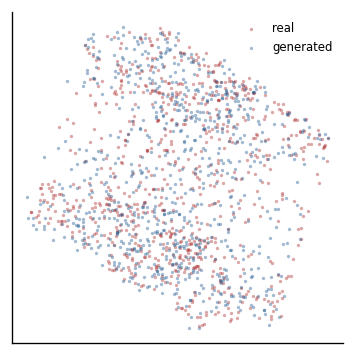

In [10]:
from sklearn.decomposition import PCA
k = min(800, len(Xte), len(gen))
rng = np.random.default_rng(0)
r = np.asarray(Xte)[rng.choice(len(Xte), k, replace=False)].reshape(k, -1)
g = gen[rng.choice(len(gen), k, replace=False)].reshape(k, -1)
pc = PCA(n_components=2, random_state=0).fit(r)
rp, gp = pc.transform(r), pc.transform(g)

fig, ax = plt.subplots(figsize=(3.0, 3.0))
ax.scatter(rp[:, 0], rp[:, 1], s=4, c=REAL_C, alpha=.4, lw=0, label="real")
ax.scatter(gp[:, 0], gp[:, 1], s=4, c=GEN_C, alpha=.4, lw=0, label="generated")
ax.set_xticks([]); ax.set_yticks([]); ax.legend(frameon=False, fontsize=7)
fig.tight_layout(); plt.show()

## Save

Written in the layout the other two notebooks and `scripts/evaluate_saved.py`
expect: the `generated` and `real_test` arrays are what every metric is computed
from.

In [11]:
OUT = os.path.join("results", "run", f"{DATASET}_sfmtime")
os.makedirs(OUT, exist_ok=True)

np.savez_compressed(os.path.join(OUT, f"{DATASET}_sfmtime_data.npz"),
                    generated=gen, real_train=np.asarray(Xtr),
                    real_val=np.asarray(Xva), real_test=np.asarray(Xte))
torch.save({"ema": trainer.ema.shadow.state_dict()}, os.path.join(OUT, "ckpt.pt"))
json.dump({"dataset": DATASET, "tag": f"{DATASET}_sfmtime", "config": cfg.to_dict(),
           "summary": info, "health_check": health, "nfe": trainer.last_nfe,
           "seq_len": SEQ_LEN, "n_features": N_FEATURES,
           "train_minutes": round(train_min, 2),
           "sample_ms_per_sequence": round(ms, 3), "n_generated": int(len(gen)),
           "history": trainer.history},
          open(os.path.join(OUT, "run.json"), "w"), indent=2)
print("wrote", OUT)

wrote results/run/sines_sfmtime
